# Chapter 8: Acting in the Dark

The document appears ready, but the controller cannot directly see whether the hidden review state is valid. Acting on the most likely state may work, yet an additional observation could change which action is best. The observation's value comes from its effect on a decision, not from how detailed its text looks.

This notebook maintains a probability distribution over hidden states. It first predicts through a transition kernel, then updates with the observed signal. A separate calculation averages over every possible signal to price gathering information before acting. The changed case uses an observation that looks different on the surface but has identical state-conditioned distributions, exposing the difference between receiving data and learning something useful.

**Outcome:** Update a belief and calculate gross and net one-step information value.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

The predictive belief is b_minus(j)=sum_i b(i)P(j|i). For observation o, its probability is Z(o)=sum_j b_minus(j)O(o|j), and Bayes' rule gives b_plus(j)=b_minus(j)O(o|j)/Z(o). An observation with Z(o)=0 is impossible under the declared model and is rejected.

For reward vector r_a, acting now has value max_a sum_j b_minus(j)r_a(j). If the controller first observes, its gross expected decision value is sum_o Z(o) max_a sum_j b_plus_o(j)r_a(j). Gross value of information is the difference between that quantity and acting now. Net value subtracts the observation cost.

The maximum is taken after each possible observation because the action can adapt to the signal. Placing the maximum before averaging would price a fixed action and lose the decision benefit. An informative signal can still have zero value when it never changes the optimal action. Identical observation rows convey no state information at all. These are one-step values; the calculation does not solve a general partially observable planning problem.

## Apply this to an agent

The agent cannot directly observe every fact needed for release. Represent uncertainty as a belief, then compare acting now with acquiring an observation and choosing afterwards. A highly probable observation can still have no decision value.

## A calculation you can run

Provide a prior belief, transition matrix, observation matrix, reward vector for each action, observed index, and observation cost. Kernel dimensions must align, all probability rows must normalize, and the observed index must exist. The function predicts belief, evaluates the observation likelihood, forms its posterior, and selects the best posterior action.

It then repeats the posterior calculation for every possible observation to obtain information value. The first plot compares prior, predictive, and posterior probability of state zero. The second varies observation cost while holding gross benefit fixed. In the changed case, replace the observation rows with identical distributions. Predict both the posterior and information value before execution.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 8
inputs = {'belief': [0.5, 0.5],
 'transition': [[1, 0], [0, 1]],
 'observation': [[0.9, 0.1], [0.1, 0.9]],
 'observed': 0,
 'action_rewards': [[10, -10], [-10, 10]],
 'observation_cost': 1}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 8: belief-information
Should a controller act now or buy an observation before choosing?
Evidence: constructed teaching example

Calculated quantities:
{
  "predictive_belief": [
    0.5,
    0.5
  ],
  "posterior": [
    0.9,
    0.1
  ],
  "observed_probability": 0.5,
  "act_now_value": 0.0,
  "observe_then_act_value": 7.0,
  "gross_value_of_information": 8.0,
  "net_value_of_information": 7.0,
  "posterior_action": 0
}

Interpretation:
Bayes' rule updates the belief, while information value averages optimal later decisions over all possible observations.

Assumptions:
- Transition precedes observation.
- Information arrives before one decision.
- Observation incurs the declared cost.

Limitations:
- A likely observation is not necessarily useful; identical observation rows give no information.

Execution: completed locally; constructed inputs are not deployment measurements.


The default prior is equally split and the transition preserves it. Observation zero produces posterior [0.9,0.1]. Acting now has value zero because either action has equally weighted gains and losses. After observing, the controller can choose the appropriate action, giving expected value 8 before cost and 7 after cost.

The gross information value is therefore 8. With identical observation rows in the changed case, the posterior remains [0.5,0.5] regardless of the signal. Gross information value falls to zero and net information value becomes -1. The signal still arrives, but it does not earn its cost.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


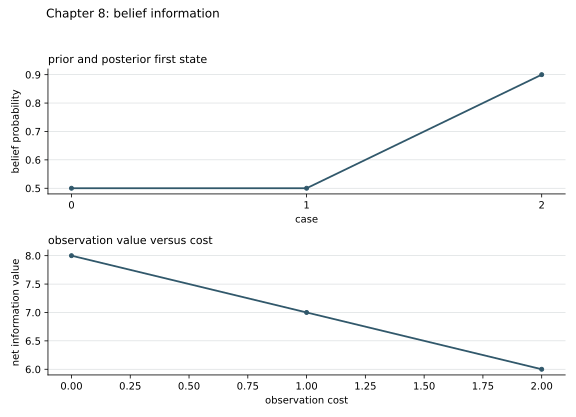

In [3]:
display(SVG(figure_svg(report)))

**Figure 8.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

A belief update can be mathematically correct under an incorrect observation model. If a tool's signal changes distribution, or if hidden states were defined too coarsely, the posterior can look confident without being calibrated. Inspect the likelihood source rather than treating normalization as validation of the world model.

Information also has opportunity cost. The implemented cost is a single utility deduction; a deadline or state transition during observation would require a larger model. Likewise, this function assumes the same action set remains available after the observation.

An impossible signal should not be assigned an arbitrary uniform posterior. It is evidence that the declared boundary is incomplete or the input is inconsistent. The rejection asks you to repair that model rather than fabricate a belief. Preserve unmodeled outcomes in the next measurement design.

Chapter 8: belief-information
Should a controller act now or buy an observation before choosing?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "predictive_belief": [
    0.5,
    0.5
  ],
  "posterior": [
    0.5,
    0.5
  ],
  "observed_probability": 0.5,
  "act_now_value": 0.0,
  "observe_then_act_value": -1.0,
  "gross_value_of_information": 0.0,
  "net_value_of_information": -1.0,
  "posterior_action": 0
}

Interpretation:
Bayes' rule updates the belief, while information value averages optimal later decisions over all possible observations.

Assumptions:
- Transition precedes observation.
- Information arrives before one decision.
- Observation incurs the declared cost.

Limitations:
- A likely observation is not necessarily useful; identical observation rows give no information.

Execution: completed locally; constructed inputs are not deployment measurements.


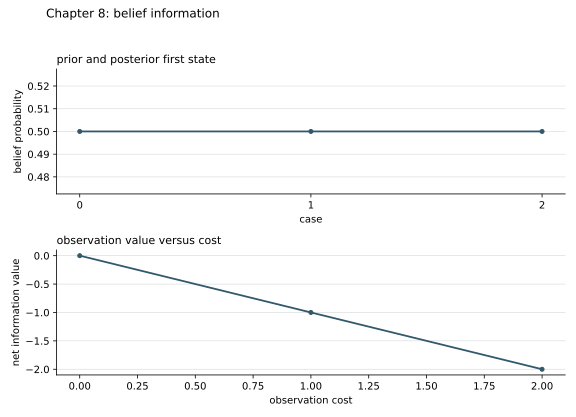

In [4]:
changed_inputs = {'belief': [0.5, 0.5],
 'transition': [[1, 0], [0, 1]],
 'observation': [[0.5, 0.5], [0.5, 0.5]],
 'observed': 0,
 'action_rewards': [[10, -10], [-10, 10]],
 'observation_cost': 1}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 8.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer case predicts a new belief before receiving observation one. Its transition mixes the initial states, so the prior is not the correct distribution to insert directly into Bayes' rule. First calculate the predictive belief [0.6,0.4], then weight it by observation-one likelihoods [0.2,0.7] and normalize.

Use local data only when the state, observation, and action definitions share one boundary. If likelihoods are fitted estimates, retain their sample sizes and calibration limits outside this exact calculation. Report gross information value separately from cost so a negative net result can be traced to unhelpful evidence, high price, or both.

In [5]:
transfer_inputs = {'belief': [0.8, 0.2],
 'transition': [[0.7, 0.3], [0.2, 0.8]],
 'observation': [[0.8, 0.2], [0.3, 0.7]],
 'observed': 1,
 'action_rewards': [[5, -4], [0, 2]],
 'observation_cost': 0.2}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 8: belief-information
Should a controller act now or buy an observation before choosing?
Evidence: constructed transfer example

Calculated quantities:
{
  "predictive_belief": [
    0.6,
    0.4
  ],
  "posterior": [
    0.3,
    0.7
  ],
  "observed_probability": 0.4,
  "act_now_value": 1.4,
  "observe_then_act_value": 2.28,
  "gross_value_of_information": 1.08,
  "net_value_of_information": 0.88,
  "posterior_action": 1
}

Interpretation:
Bayes' rule updates the belief, while information value averages optimal later decisions over all possible observations.

Assumptions:
- Transition precedes observation.
- Information arrives before one decision.
- Observation incurs the declared cost.

Limitations:
- A likely observation is not necessarily useful; identical observation rows give no information.

Execution: completed locally; constructed inputs are not deployment measurements.


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **belief:** Normalized prior state probability list.
- **transition:** Square row-stochastic state transition matrix.
- **observation:** State by observation row-stochastic matrix.
- **observed:** Zero-based observation index.
- **action_rewards:** Action by state finite reward matrix.
- **observation_cost:** Nonnegative cost paid before the one later action.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch08.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 8: belief-information
Should a controller act now or buy an observation before choosing?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "predictive_belief": [
    0.6,
    0.4
  ],
  "posterior": [
    0.3,
    0.7
  ],
  "observed_probability": 0.4,
  "act_now_value": 1.4,
  "observe_then_act_value": 2.28,
  "gross_value_of_information": 1.08,
  "net_value_of_information": 0.88,
  "posterior_action": 1
}

Interpretation:
Bayes' rule updates the belief, while information value averages optimal later decisions over all possible observations.

Assumptions:
- Transition precedes observation.
- Information arrives before one decision.
- Observation incurs the declared cost.

Limitations:
- A likely observation is not necessarily useful; identical observation rows give no information.

Execution: completed locally; constructed inputs are not deployment measurements.


## Explore the four chapter demonstrations

The following sections reproduce every demonstration in the illustrated chapter reader. They use the same declared controls, calculation and figure. Begin with the prediction, run the worked case, change one control, then inspect the complete state table. The chapter experiment above remains available for your own compatible inputs.

In [7]:
from math_ai_agents.demos import demo_catalog, demo_states, run_demo, demo_report_text

<a id="demo-c08-d01"></a>

### Demonstration 1: The belief update, one stage at a time

How does a belief change when an action is taken and a report arrives, and which part of the change is prediction and which is correction?

![Equation 8.1](../assets/math/e992bac4f67c2b9f4efc.svg)

![Equation un-numbered display 2](../assets/math/aeaa392b80c6a5400cb4.svg)

**Symbols and units:** b is the belief: one probability per state. In the corridor there are four places numbered 1 to 4 from west to east, place 3 is the goal, and an EAST move goes east with chance 0.9 and west with chance 0.1 (a move into a wall leaves the robot in place). In Equation (8.1), a is the action, P(x' | x, a) the chance that action a moves state x to x', Obs(o | x', a) the chance of hearing report o in state x' (here the report depends only on the state), and x'' a stand-in state in the rescaling sum. The notebook cases use two states: the default keeps the state fixed and hears observation 0 from a sensor with rows (0.9, 0.1) and (0.1, 0.9); the transfer case moves the state with rows (0.7, 0.3) and (0.2, 0.8) and hears observation 1 from rows (0.8, 0.2) and (0.3, 0.7). The three steps are the prior, the prediction (inner sum) and the correction (weight by the report, rescale).

The prediction pushes each state's weight along the action, which is the inner sum of Equation (8.1). The report then multiplies each predicted weight by its likelihood and the denominator rescales what is left. When the action leaves the state fixed, prediction changes nothing and the prior is already the predicted belief. When it moves the state, the prior must not be inserted straight into the weighting step. The west end of the corridor never reaches 0 because nothing the robot has heard rules it out.

**Use in this chapter:** Whenever a tool result leaves several explanations open, write down the possibilities, the chance the action moved each one, and the chance each would have produced the report. The three steps then give the new weights without rereading the whole history.

**Assumptions:** The corridor, its deterministic goal report and the move probabilities are the chapter's; the notebook cases are constructed. The model is only as good as the move and report probabilities supplied to it; if the real world differs, the update is exact for the wrong world.

**Predict before running:** In the notebook transfer case the prior is (0.8, 0.2). After the prediction step, before the report is used, is the belief still (0.8, 0.2)?

**Controls you can change:**

- **Case:** `case` accepts 'move1', 'move2', 'default', 'transfer'.
- **Step:** `stage` accepts 0, 1, 2.

**Source section:** The update, worked.

**Evidence:** constructed teaching example.

Constructed example: the chapter's corridor update (the book's own values for one and two moves at slip chance 0.1) and the laboratory notebook's default and transfer cases, computed with the laboratory's belief function.

Prediction choices:

1. Yes, prediction leaves it unchanged
2. No, it becomes (0.6, 0.4)
3. No, it becomes (0.2, 0.8)

**Boundary of the conclusion:** The belief formulation assumes the transition and observation kernels are known, and an agent operating on real tools has neither.

**Common wrong turn:** The chapter says a belief does not converge on the truth merely by running longer; it converges only as far as the evidence distinguishes. In the corridor the west end falls to 0.100 and holds there across the paper's two moves, because no report rules it out.

The belief update, one stage at a time
Controls: {"case": "move1", "stage": 2}
Evidence: constructed teaching example

Calculated quantities:
Prior belief: 0.333, 0.333, 0.000, 0.333
Predicted belief: 0.067, 0.300, 0.333, 0.300
Belief after the report: 0.100, 0.450, 0.000, 0.450
Weight the report keeps: 0.667
First coordinate (place 1) after the report: 0.100

Worked steps:
1. Predicted belief (0.067, 0.300, 0.333, 0.300); the report's likelihood in each state is (1.000, 1.000, 0.000, 1.000).
2. Weight kept = 0.067 x 1.000 + 0.300 x 1.000 + 0.300 x 1.000 = 0.667.
3. Place 1 = 0.067 x 1.000 / 0.667 = 0.100.
4. Place 2 = 0.300 x 1.000 / 0.667 = 0.450.
5. The belief after the report is (0.100, 0.450, 0.000, 0.450).

The non-goal report keeps weight 0.067 x 1.000 + 0.300 x 1.000 + 0.300 x 1.000 = 0.667. Place 1 after the report = 0.067 x 1.000 / 0.667 = 0.100; place 2 = 0.300 x 1.000 / 0.667 = 0.450. The belief after the report is (0.100, 0.450, 0.000, 0.450). A state the report rules out 

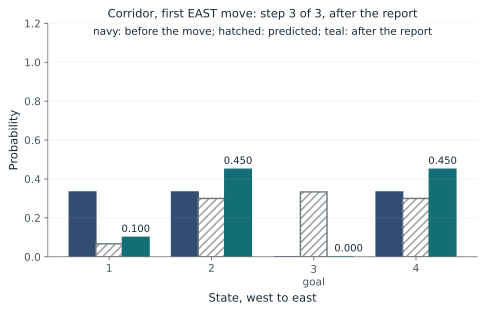

In [8]:
demo_id = 'C08-D01'
demo_controls = {'case': 'move1', 'stage': 2}
demo_result = run_demo(8, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Case** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

The belief update, one stage at a time
Controls: {"case": "move2", "stage": 2}
Evidence: constructed teaching example

Calculated quantities:
Prior belief: 0.100, 0.450, 0.000, 0.450
Predicted belief: 0.055, 0.090, 0.450, 0.405
Belief after the report: 0.100, 0.164, 0.000, 0.736
Weight the report keeps: 0.550
First coordinate (place 1) after the report: 0.100

Worked steps:
1. Predicted belief (0.055, 0.090, 0.450, 0.405); the report's likelihood in each state is (1.000, 1.000, 0.000, 1.000).
2. Weight kept = 0.055 x 1.000 + 0.090 x 1.000 + 0.405 x 1.000 = 0.550.
3. Place 1 = 0.055 x 1.000 / 0.550 = 0.100.
4. Place 2 = 0.090 x 1.000 / 0.550 = 0.164.
5. The belief after the report is (0.100, 0.164, 0.000, 0.736).

The non-goal report keeps weight 0.055 x 1.000 + 0.090 x 1.000 + 0.405 x 1.000 = 0.550. Place 1 after the report = 0.055 x 1.000 / 0.550 = 0.100; place 2 = 0.090 x 1.000 / 0.550 = 0.164. The belief after the report is (0.100, 0.164, 0.000, 0.736). A state the report rules out 

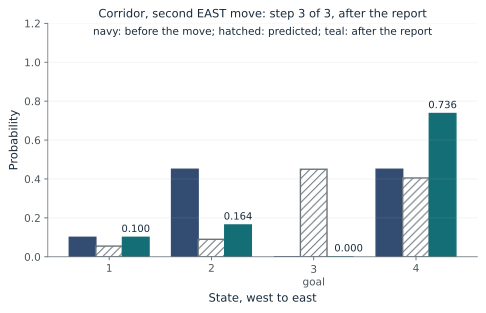

In [9]:
changed_controls = {'case': 'move2', 'stage': 2}
changed_demo = run_demo(8, 'C08-D01', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [10]:
state_rows = []
for controls in demo_states(8, 'C08-D01'):
    state = run_demo(8, 'C08-D01', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "case": "move1",
      "stage": 0
    },
    "metrics": [
      [
        "Prior belief",
        "0.333, 0.333, 0.000, 0.333"
      ],
      [
        "Predicted belief",
        "not computed yet"
      ],
      [
        "Belief after the report",
        "not computed yet"
      ],
      [
        "Weight the report keeps",
        "not computed yet"
      ],
      [
        "First coordinate (place 1) after the report",
        "not computed yet"
      ]
    ]
  },
  {
    "controls": {
      "case": "move1",
      "stage": 1
    },
    "metrics": [
      [
        "Prior belief",
        "0.333, 0.333, 0.000, 0.333"
      ],
      [
        "Predicted belief",
        "0.067, 0.300, 0.333, 0.300"
      ],
      [
        "Belief after the report",
        "not computed yet"
      ],
      [
        "Weight the report keeps",
        "not computed yet"
      ],
      [
        "First coordinate (place 1) after the report",
        "not computed yet"
 

**Check your understanding:** Start from (1/3, 1/3, 0, 1/3) with a move that goes west with chance 0.2 instead of 0.1. What is the west-end weight after the first non-goal report?

[Answer and worked reasoning](../solutions/ch08.md#demonstration-1). [Matching browser demonstration](../readers/08-belief-information/reader.html#C08-D01).

<a id="demo-c08-d02"></a>

### Demonstration 2: The same report under different instruments

If an instrument says pass, how far does the belief move, and what decides that: the report or the instrument model?

![Equation 8.1](../assets/math/e992bac4f67c2b9f4efc.svg)

**Symbols and units:** The runner has two modeled states: the tests genuinely pass, or they do not (failed or never ran). A passing state always reports pass; the false-positive probability is the chance that a not-passing state also reports pass. The sensor kernels have two states: the informative sensor reports observation 0 with chance 0.9 in the first state and 0.1 in the second; the aliased sensor has identical rows, so observation 0 has chance 0.5 in both. The prior is the probability of the first state before the report. The dotted diagonal is a report that carries no information (posterior equals prior). The dashed line is the belief at which the decision flips.

Equation (8.1) weights the first state by its report chance and the second by its own, then rescales. When the report chances differ a lot the posterior curve bows far from the diagonal; when they are equal it lies on the diagonal and the report carries nothing. Noise corrupts a reading that still discriminates; aliasing gives distinct states the same reading, and no operation on that reading recovers the difference. Holding the prior fixed, only the assumed instrument changes, and with it the conclusion.

**Use in this chapter:** Before trusting a pass, a green check or a found-nothing result, ask how often the bad state produces the same output. That one comparison decides whether the report can carry a decision.

**Assumptions:** Two states, one report, and instrument probabilities that are teaching assumptions, not measurements of any runner or sensor. Correct arithmetic cannot repair a wrong likelihood. Repeated reports would need a model of how they depend on each other; rerunning the same broken or cached instrument does not automatically supply independent evidence.

**Predict before running:** Keep the prior at 0.50 and move from the runner with false-positive probability 0.03 to the one with 0.30. Does the posterior cross the 0.80 threshold, and in which direction?

**Controls you can change:**

- **Instrument:** `kernel` accepts 'run03', 'run30', 'sensor', 'aliased'.
- **Prior probability of the first state:** `prior` accepts 0.2, 0.5, 0.8.

**Source section:** Where the observation kernel comes from.

**Evidence:** constructed teaching example.

Constructed example: the chapter's test-runner teaching assumptions (true-positive 1, false-positive 0.03 and 0.30, prior 0.5, giving 0.9709 and 0.7692) and the laboratory notebook's default and changed observation rows, with priors 0.2 and 0.8 defined for this reader.

Prediction choices:

1. It rises further above 0.80
2. It falls from above 0.80 to below it
3. It stays above 0.80

**Boundary of the conclusion:** A correct application of Bayes' rule cannot repair an incorrect likelihood supplied to it.

**Common wrong turn:** The chapter separates noise from aliasing. More samples, better optics and longer integration attack noise and help. When two states give the same reading, averaging more readings returns the same ambiguity with tighter error bars: the information was never in the observation.

The same report under different instruments
Controls: {"kernel": "run03", "prior": 0.5}
Evidence: constructed teaching example

Calculated quantities:
Chance of this report: 0.5150
Posterior, first state: 0.9709
Compared with the threshold: above the threshold
Change from the prior: 0.4709

Worked steps:
1. The report has chance 1.00 in tests pass and 0.03 in not passing.
2. Weight of tests pass = 0.50 x 1.00 = 0.5000.
3. Weight of not passing = 0.50 x 0.03 = 0.0150.
4. Chance of the report = 0.5000 + 0.0150 = 0.5150.
5. Posterior = 0.5000 / 0.5150 = 0.9709.
6. Compared with the 0.80 release threshold: above the threshold.

Posterior = 0.50 x 1.00 / (0.50 x 1.00 + 0.50 x 0.03) = 0.5000 / 0.5150 = 0.9709, above the threshold (the 0.80 release threshold). Only the assumed instrument differs between the kernels; the report is the same.

Assumptions: Two states, one report, and instrument probabilities that are teaching assumptions, not measurements of any runner or sensor. Correct arithme

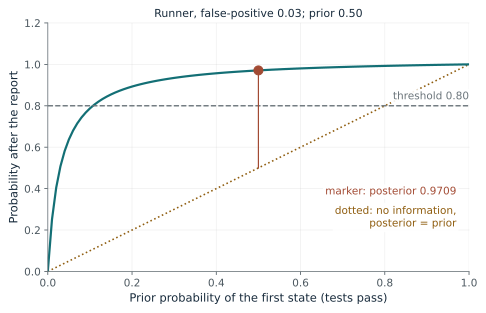

In [11]:
demo_id = 'C08-D02'
demo_controls = {'kernel': 'run03', 'prior': 0.5}
demo_result = run_demo(8, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Instrument** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

The same report under different instruments
Controls: {"kernel": "run30", "prior": 0.5}
Evidence: constructed teaching example

Calculated quantities:
Chance of this report: 0.6500
Posterior, first state: 0.7692
Compared with the threshold: below the threshold
Change from the prior: 0.2692

Worked steps:
1. The report has chance 1.00 in tests pass and 0.30 in not passing.
2. Weight of tests pass = 0.50 x 1.00 = 0.5000.
3. Weight of not passing = 0.50 x 0.30 = 0.1500.
4. Chance of the report = 0.5000 + 0.1500 = 0.6500.
5. Posterior = 0.5000 / 0.6500 = 0.7692.
6. Compared with the 0.80 release threshold: below the threshold.

Posterior = 0.50 x 1.00 / (0.50 x 1.00 + 0.50 x 0.30) = 0.5000 / 0.6500 = 0.7692, below the threshold (the 0.80 release threshold). Only the assumed instrument differs between the kernels; the report is the same.

Assumptions: Two states, one report, and instrument probabilities that are teaching assumptions, not measurements of any runner or sensor. Correct arithme

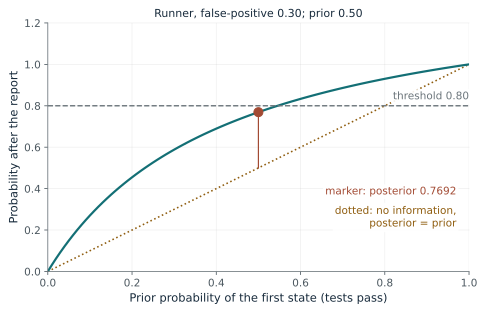

In [12]:
changed_controls = {'kernel': 'run30', 'prior': 0.5}
changed_demo = run_demo(8, 'C08-D02', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [13]:
state_rows = []
for controls in demo_states(8, 'C08-D02'):
    state = run_demo(8, 'C08-D02', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "kernel": "run03",
      "prior": 0.2
    },
    "metrics": [
      [
        "Chance of this report",
        "0.2240"
      ],
      [
        "Posterior, first state",
        "0.8929"
      ],
      [
        "Compared with the threshold",
        "above the threshold"
      ],
      [
        "Change from the prior",
        "0.6929"
      ]
    ]
  },
  {
    "controls": {
      "kernel": "run03",
      "prior": 0.5
    },
    "metrics": [
      [
        "Chance of this report",
        "0.5150"
      ],
      [
        "Posterior, first state",
        "0.9709"
      ],
      [
        "Compared with the threshold",
        "above the threshold"
      ],
      [
        "Change from the prior",
        "0.4709"
      ]
    ]
  },
  {
    "controls": {
      "kernel": "run03",
      "prior": 0.8
    },
    "metrics": [
      [
        "Chance of this report",
        "0.8060"
      ],
      [
        "Posterior, first state",
        "0.9926"
      

**Check your understanding:** With prior 0.50 and a runner that always reports pass when the tests pass, what false-positive probability puts the posterior exactly at 0.80?

[Answer and worked reasoning](../solutions/ch08.md#demonstration-2). [Matching browser demonstration](../readers/08-belief-information/reader.html#C08-D02).

<a id="demo-c08-d03"></a>

### Demonstration 3: A belief is valued by its best plan

If every plan is a straight line in the belief, what does the belief's value look like, and how can two equal memories give different values?

![Equation 8.2](../assets/math/c2b31b3a9ae02b649313.svg)

![Equation 8.3](../assets/math/cd4610a982670be0201e.svg)

![Equation 8.4](../assets/math/a29d857519b0a313b7c7.svg)

**Symbols and units:** b is the belief, here the probability of the first state (the second has 1 - b). A plan has a reward in each state; its expected reward at the belief, Equation (8.2), is the weighted average, which is the dot product of the plan's vector alpha with b. V(b) is the best such value, the highest line, as in Equations (8.3) and (8.4). The settings are: the chapter's two plans alpha1 = (4, 1) and alpha2 = (0, 3); the one-bit memories of the document-release task (release earns 4 when authorized and -12 when not, holding earns 0); and the three-move detour (commit earns 100 with the chance that the committed route is right; the chapter stipulates 97 for the detour, which equals 100 - 3 if routing then succeeds for certain).

Equation (8.2) makes each plan's value linear in the belief, so each plan is a line and the value of the belief is the highest line, a piecewise linear convex curve. The two memories show why the belief matters more than storage size: keeping authorization gives a belief of 1 or 0 and a mean utility of 2, while keeping the formatting letter leaves belief 0.5 and, because release also needs the authorization record, a mean utility of 0. A look is just another action with a negative immediate reward, so the detour is priced by the same maximum.

**Use in this chapter:** When shrinking a summary or a memory, list the histories it merges and check whether the best allowed action agrees across each merged group. Equal size says nothing; what the retained bit distinguishes is what matters.

**Assumptions:** A stipulated toy task: four equally likely histories, authorization fixed between observation and action, and release permitted only with an authoritative authorization record. The detour value 97 is stipulated, not derived. This shows decision sufficiency for one task, not that short summaries are better in general, and the finite-horizon vector form does not make planning cheap.

**Predict before running:** At belief 0.25 on the first state, which of the chapter's plans (4, 1) and (0, 3) has the larger expected reward?

**Controls you can change:**

- **Setting:** `setting` accepts 'alpha', 'auth', 'fmt', 'detour'.
- **Case within the setting (named in the figure):** `case` accepts 0, 1, 2.

**Source section:** Where an agent's belief actually lives.

**Evidence:** constructed teaching example.

Constructed example: the chapter's alpha-vector pair, its four-history document-release table with the book's stipulated utilities (+4, -12 and 0) and its three-move detour (100, cost 3, value 97), with the break-even belief 0.97 derived from them; maxima checked with the laboratory's expected-reward function.

Prediction choices:

1. Plan 1, with 1.75
2. Plan 2, with 2.25
3. They tie

**Boundary of the conclusion:** Equation (8.3) is a solution concept rather than an algorithm, and the space it ranges over cannot be enumerated.

**Common wrong turn:** The chapter notes the belief reward can seem strange, as if the agent were rewarded merely for believing it will be paid. Equation (8.2) is an expected reward, not a payment for confidence; actual rewards depend on the realized state and chosen action.

A belief is valued by its best plan
Controls: {"setting": "alpha", "case": 1}
Evidence: constructed teaching example

Calculated quantities:
Value of plan 1: 2.50
Value of plan 2: 1.50
Belief value V(b) (the larger): 2.50
Chosen: plan 1
Crossing belief: 0.333

Worked steps:
1. Belief on the first state = 0.50, so the second state has 0.50.
2. plan 1: 4 x 0.50 + 1 x 0.50 = 2.50.
3. plan 2: 0 x 0.50 + 3 x 0.50 = 1.50.
4. The belief value is the larger: 2.50 (plan 1).
5. The lines cross at belief 0.333.

Belief 0.50. plan 1: 4 x 0.50 + 1 x 0.50 = 2.50; plan 2: 0 x 0.50 + 3 x 0.50 = 1.50. The larger is 2.50, so plan 1 is chosen. The two plans cross at belief 0.333. The belief value is the highest line at the belief, as in Equation (8.4): a plan is a vector, the value its dot product with the belief.

Assumptions: A stipulated toy task: four equally likely histories, authorization fixed between observation and action, and release permitted only with an authoritative authorization record. Th

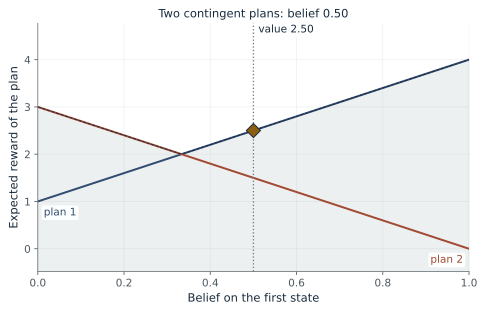

In [14]:
demo_id = 'C08-D03'
demo_controls = {'setting': 'alpha', 'case': 1}
demo_result = run_demo(8, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Setting** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

A belief is valued by its best plan
Controls: {"setting": "auth", "case": 1}
Evidence: constructed teaching example

Calculated quantities:
Value of release: (-12.00)
Value of hold: 0.00
Belief value V(b) (the larger): 0.00
Chosen: hold
Crossing belief: 0.750
Mean utility over four histories: authorization memory against formatting memory: 2.0 against 0.0

Worked steps:
1. Belief on the first state = 0.00, so the second state has 1.00.
2. release: 4 x 0.00 + (-12) x 1.00 = (-12.00).
3. hold: 0 x 0.00 + 0 x 1.00 = 0.00.
4. The belief value is the larger: 0.00 (hold).
5. The lines cross at belief 0.750.

Belief 0.00. release: 4 x 0.00 + (-12) x 1.00 = (-12.00); hold: 0 x 0.00 + 0 x 1.00 = 0.00. The larger is 0.00, so hold is chosen. The two plans cross at belief 0.750. Belief 0: hold is best. Mean utility over the four histories with this memory = (4 + 4 + 0 + 0) / 4 = 2.0, the same as the full history.

Assumptions: A stipulated toy task: four equally likely histories, authorization fix

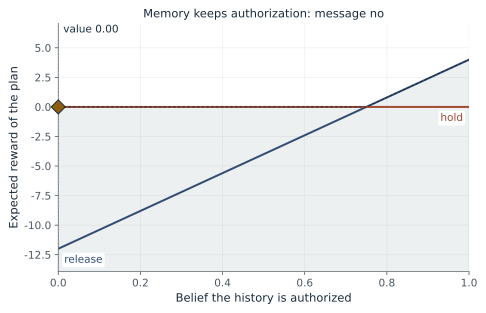

In [15]:
changed_controls = {'setting': 'auth', 'case': 1}
changed_demo = run_demo(8, 'C08-D03', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [16]:
state_rows = []
for controls in demo_states(8, 'C08-D03'):
    state = run_demo(8, 'C08-D03', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "setting": "alpha",
      "case": 0
    },
    "metrics": [
      [
        "Value of plan 1",
        "1.75"
      ],
      [
        "Value of plan 2",
        "2.25"
      ],
      [
        "Belief value V(b) (the larger)",
        "2.25"
      ],
      [
        "Chosen",
        "plan 2"
      ],
      [
        "Crossing belief",
        "0.333"
      ]
    ]
  },
  {
    "controls": {
      "setting": "alpha",
      "case": 1
    },
    "metrics": [
      [
        "Value of plan 1",
        "2.50"
      ],
      [
        "Value of plan 2",
        "1.50"
      ],
      [
        "Belief value V(b) (the larger)",
        "2.50"
      ],
      [
        "Chosen",
        "plan 1"
      ],
      [
        "Crossing belief",
        "0.333"
      ]
    ]
  },
  {
    "controls": {
      "setting": "alpha",
      "case": 2
    },
    "metrics": [
      [
        "Value of plan 1",
        "3.25"
      ],
      [
        "Value of plan 2",
        "0.7

**Check your understanding:** For plans (4, 1) and (0, 3), at what belief on the first state do they tie?

[Answer and worked reasoning](../solutions/ch08.md#demonstration-3). [Matching browser demonstration](../readers/08-belief-information/reader.html#C08-D03).

<a id="demo-c08-d04"></a>

### Demonstration 4: A look pays only near the threshold

For which beliefs can a report change the decision, and is the change worth its price?

![Equation 8.5](../assets/math/56c0b286f79d620e6ec3.svg)

**Symbols and units:** VOI(O) is the average of the best expected reward after each report minus the best expected reward without looking. Pr(o | b) is the chance of report o. In the chapter's verification tool, releasing a supported claim earns 10, an unsupported one loses 40, declining earns 0, the tool reports pass on 90 percent of supported claims and fail on 85 percent of unsupported ones, and releasing beats declining when the belief is above 0.8. The notebook cases use rewards (10, -10) and (-10, 10) for default and changed, and (5, -4) and (0, 2) for transfer. The curve shows the value against the belief at the moment of decision. The price is zero, the case's own price, or the break-even price equal to the value.

After each report the controller picks its best action, and Equation (8.5) averages those best rewards by how likely each report is. If the same action is best after every report, the average equals the best reward without looking and the value is exactly 0. Only beliefs where a report can push the decision across its threshold give a positive value, and the chapter's tool peaks at 0.8 where the two actions tie. Free information never hurts; priced information must clear its price.

**Use in this chapter:** Before paying for a check, ask whether any answer it could give would change what you do. If not, its value is 0 however reassuring it sounds. If so, compare the value with the price of the check.

**Assumptions:** One report, one decision afterward, a fixed price for looking, and the stipulated rewards and rates. The band describes beliefs, not how often cases land in it. Real tools can fail in ways the rates do not describe, and checking takes time that a single price may not capture. The price 1.0 for the chapter's tool is defined for this reader.

**Predict before running:** In the notebook changed case the two observation rows are identical. Is one report worth anything?

**Controls you can change:**

- **Case:** `case` accepts 'tool', 'default', 'changed', 'transfer'.
- **Price of the look:** `price` accepts 'free', 'case', 'even'.

**Source section:** The condition that makes a look worthless.

**Evidence:** constructed teaching example.

Constructed example: the chapter's verification-tool instance (rewards 10, -40 and 0; pass 0.90 and fail 0.85; value 3.0 at prior 0.6), and the laboratory notebook's default, changed and transfer cases, computed with the laboratory's belief function; the price 1.0 is defined for this reader.

Prediction choices:

1. Yes, about 8
2. No, exactly 0
3. Yes, about 1

**Boundary of the conclusion:** The worked release numbers are constructed for teaching.

**Common wrong turn:** The chapter says uncertainty reduction earns its cost only through the decisions it can improve. Information stops being a virtue and becomes a line item: a look that never changes the action is worth exactly 0 however much it changes the belief.

A look pays only near the threshold
Controls: {"case": "tool", "price": "free"}
Evidence: constructed teaching example

Calculated quantities:
Best action without looking: decline (0.00)
Value of looking (gross): 3.00
Price of looking: 0.00
Net value of looking: 3.00
Decision: look

Worked steps:
1. Belief when the decision is made: (0.60, 0.40).
2. Acting now: release (-10.000), decline 0.000; best 0.00.
3. After report 0 (weighted by its chance): release 3.00, decline 0.00; best 3.00.
4. After report 1 (weighted by its chance): release (-13.00), decline 0.00; best 0.00.
5. Value of looking = 3.00 + 0.00 - 0.00 = 3.00.
6. Price 0.00: net = 3.00 - 0.00 = 3.00.

Belief at the decision (0.60, 0.40). Acting now: release (-10.000), decline 0.000, best 0.00. Each term after a report is weighted by the chance of the report: report 0: release 3.00, decline 0.00, best release 3.00; report 1: release (-13.00), decline 0.00, best decline 0.00. Value of looking = 3.00 + 0.00 - 0.00 = 3.00. The lo

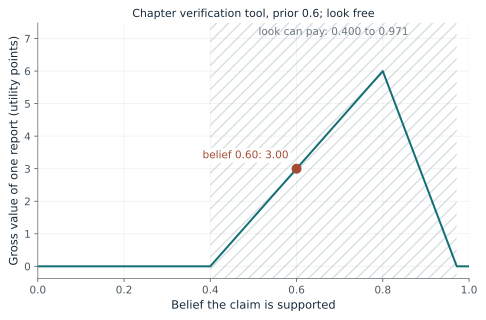

In [17]:
demo_id = 'C08-D04'
demo_controls = {'case': 'tool', 'price': 'free'}
demo_result = run_demo(8, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Case** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

A look pays only near the threshold
Controls: {"case": "default", "price": "free"}
Evidence: constructed teaching example

Calculated quantities:
Best action without looking: act 1 (0.00)
Value of looking (gross): 8.00
Price of looking: 0.00
Net value of looking: 8.00
Decision: look

Worked steps:
1. Belief when the decision is made: (0.50, 0.50).
2. Acting now: act 1 0.000, act 2 0.000; best 0.00.
3. After report 0 (weighted by its chance): act 1 4.00, act 2 (-4.00); best 4.00.
4. After report 1 (weighted by its chance): act 1 (-4.00), act 2 4.00; best 4.00.
5. Value of looking = 4.00 + 4.00 - 0.00 = 8.00.
6. Price 0.00: net = 8.00 - 0.00 = 8.00.

Belief at the decision (0.50, 0.50). Acting now: act 1 0.000, act 2 0.000, best 0.00. Each term after a report is weighted by the chance of the report: report 0: act 1 4.00, act 2 (-4.00), best act 1 4.00; report 1: act 1 (-4.00), act 2 4.00, best act 2 4.00. Value of looking = 4.00 + 4.00 - 0.00 = 8.00. The look pays: 8.00 - 0.00 = 8.00 is 

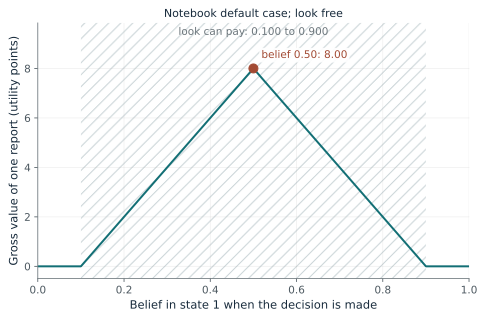

In [18]:
changed_controls = {'case': 'default', 'price': 'free'}
changed_demo = run_demo(8, 'C08-D04', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [19]:
state_rows = []
for controls in demo_states(8, 'C08-D04'):
    state = run_demo(8, 'C08-D04', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "case": "tool",
      "price": "free"
    },
    "metrics": [
      [
        "Best action without looking",
        "decline (0.00)"
      ],
      [
        "Value of looking (gross)",
        "3.00"
      ],
      [
        "Price of looking",
        "0.00"
      ],
      [
        "Net value of looking",
        "3.00"
      ],
      [
        "Decision",
        "look"
      ]
    ]
  },
  {
    "controls": {
      "case": "tool",
      "price": "case"
    },
    "metrics": [
      [
        "Best action without looking",
        "decline (0.00)"
      ],
      [
        "Value of looking (gross)",
        "3.00"
      ],
      [
        "Price of looking",
        "1.00"
      ],
      [
        "Net value of looking",
        "2.00"
      ],
      [
        "Decision",
        "look"
      ]
    ]
  },
  {
    "controls": {
      "case": "tool",
      "price": "even"
    },
    "metrics": [
      [
        "Best action without looking",
        "de

**Check your understanding:** With the chapter's tool, prior 0.5 and no price, what is the value of the look?

[Answer and worked reasoning](../solutions/ch08.md#demonstration-4). [Matching browser demonstration](../readers/08-belief-information/reader.html#C08-D04).

## Questions

1. Compute default posterior.

2. What observation cost makes default information break even?

3. Compute transfer posterior after observation 1.

Answers: [separate solutions](../solutions/ch08.md). Try the calculation before opening them.

## Summary

Beliefs predict through transitions and update through observation likelihoods. Information is worth its decision improvement after cost, not its volume or apparent specificity. The default signal changes the optimal action; the changed signal is uninformative; the transfer case requires transition prediction before Bayes' rule. Keep normalization, model provenance, and action timing explicit. This notebook prices one observation and one decision within a declared hidden-state model.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-08-belief-information`](../skills/maa-08-belief-information/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 8.1

![Equation 8.1](../assets/math/e992bac4f67c2b9f4efc.svg)

Equation (8.1) turns yesterday's belief, one action, and one observation into today's belief.

Push the old belief forward through the action, weight each destination by how well it explains what was seen, then rescale so the weights sum to one.

LaTeX source, preserved for inspection:

```latex
\mathbf{b}_{t+1}(x') \;=\;
\frac{\begin{gathered}
\operatorname{Obs}(o\mid x',a)\\
\cdot\sum_{x\in\mathcal{X}}P(x'\mid x,a)\,\mathbf{b}_t(x)
\end{gathered}}
{\begin{gathered}
\sum_{x''\in\mathcal{X}}\operatorname{Obs}(o\mid x'',a)\\
\cdot\sum_{x\in\mathcal{X}}P(x''\mid x,a)\,\mathbf{b}_t(x)
\end{gathered}}.
\tag{8.1}
```

### Equation un-numbered display 2

![Equation un-numbered display 2](../assets/math/aeaa392b80c6a5400cb4.svg)



LaTeX source, preserved for inspection:

```latex
T_E=\begin{pmatrix}
0.1&0.9&0&0\\
0.1&0&0.9&0\\
0&0.1&0&0.9\\
0&0&0.1&0.9
\end{pmatrix},\qquad
\operatorname{Obs}(\text{non-goal}\mid x')=(1,1,0,1).
```

### Equation 8.2

![Equation 8.2](../assets/math/c2b31b3a9ae02b649313.svg)

Equation (8.2) prices an action under uncertainty about where the agent is.

Average the reward the action would earn in each state, weighting each state by how much belief sits on it.

LaTeX source, preserved for inspection:

```latex
\bar r(\mathbf{b},a)\;=\;\sum_{x\in\mathcal{X}}\mathbf{b}(x)\,r(x,a).
\tag{8.2}
```

### Equation 8.3

![Equation 8.3](../assets/math/cd4610a982670be0201e.svg)

Equation (8.3) values a belief by the best action available from it and the beliefs that action can lead to.

Take the immediate expected reward, add the discounted average value of the belief each possible observation would produce, and keep the best action.

LaTeX source, preserved for inspection:

```latex
\begin{aligned}
V(\mathbf{b})
&=\max_{a\in\mathcal{A}}\Big[\,\bar r(\mathbf{b},a)\\
&\quad+\gamma\sum_{o}\Pr(o\mid \mathbf{b},a)\,
V\big(\mathbf{b}'(\mathbf{b},a,o)\big)\Big].
\end{aligned}
\tag{8.3}
```

### Equation 8.4

![Equation 8.4](../assets/math/a29d857519b0a313b7c7.svg)

Equation (8.4) represents finite-horizon belief value as best dot product from finite policy-vector set.

Score each contingent plan against current belief, then select largest expected return.

LaTeX source, preserved for inspection:

```latex
V_H(\mathbf b)=\max_{\alpha\in\Gamma_H}\alpha^\top\mathbf b.
\tag{8.4}
```

### Equation 8.5

![Equation 8.5](../assets/math/56c0b286f79d620e6ec3.svg)

Equation (8.5) prices a look by how much better the decision becomes once its answer is known.

Average the best achievable reward across the beliefs each possible answer would leave, then subtract the best achievable reward without looking.

LaTeX source, preserved for inspection:

```latex
\begin{aligned}
\operatorname{VOI}(O)
&=\sum_{o}\Pr(o\mid\mathbf{b})\,
\max_{a\in\mathcal{A}}\bar r\big(\mathbf{b}'(\mathbf{b},o),a\big)\\
&\quad-\max_{a\in\mathcal{A}}\bar r(\mathbf{b},a).
\end{aligned}
\tag{8.5}
```